PUNTO 2

aplicamos aprendizaje no supervisado

In [15]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
import numpy as np

In [ ]:


census_income = fetch_ucirepo(id=20) 

# extraemos solo las x y las y
X = census_income.data.features



# Filtrar solo columnas numéricas

print("Columnas de x:")
print(X.head())

Columnas de x:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country  
0          2174             0              40  United-States  
1             0             0            

preprocesamiento de los datos

In [18]:
# Rellenamos las columnas categóricas con "Unknown"
X = X.fillna("Unknown")

In [19]:
#Identificamos tipos de columnas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [20]:
#convertimos las columnas categóricas a numéricas usando Label Encoding

from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

print(X_encoded.head(5))


   age  workclass  fnlwgt  education  education-num  marital-status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           1             1     4    1          2174             0   
1           4             0     4    1             0             0   
2           6             1     4    1             0             0   
3           6             0     2    1             0             0   
4          10             5     2    0             0             0   

   hours-per-week  native-country  
0              40              39  
1              13              39  
2              40              39  
3       

In [21]:
#normalizamos los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_nor = scaler.fit_transform(X_encoded)


In [30]:
#aplicamos k-means con diferentes iteraciones
from sklearn.cluster import KMeans,MiniBatchKMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_nor)
y_pred


array([1, 1, 1, ..., 4, 1, 1], dtype=int32)

In [23]:
# Centroides en escala original
X_centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(X_centroids_orig, columns=X_encoded.columns)
print("Centroides originales:")
print(centroids_df)

Centroides originales:
         age  workclass        fnlwgt  education  education-num  \
0  42.969221   4.136231  187312.75590  10.384809      10.351827   
1  32.765768   3.882353  192859.26601  10.157442       9.706124   

   marital-status  occupation  relationship      race       sex  capital-gain  \
0        2.008317    7.111245      0.386302  3.779855  0.937909   1579.416193   
1        3.448228    6.552497      2.879552  3.516131  0.302376    399.177388   

   capital-loss  hours-per-week  native-country  
0    115.441143       44.206177       37.086722  
1     49.538105       35.280836       36.825510  


In [24]:
kmeans.cluster_centers_

array([[ 0.31550101,  0.07316819, -0.02226622,  0.02487827,  0.10647375,
        -0.40488076,  0.0552878 , -0.65973491,  0.13215827,  0.57232433,
         0.06714337,  0.06932705,  0.30535856,  0.0152248 ],
       [-0.42871325, -0.09942336,  0.03025608, -0.03380542, -0.14468007,
         0.55016542, -0.0751269 ,  0.89646969, -0.17958105, -0.77769329,
        -0.09123664, -0.09420389, -0.41493135, -0.02068797]])

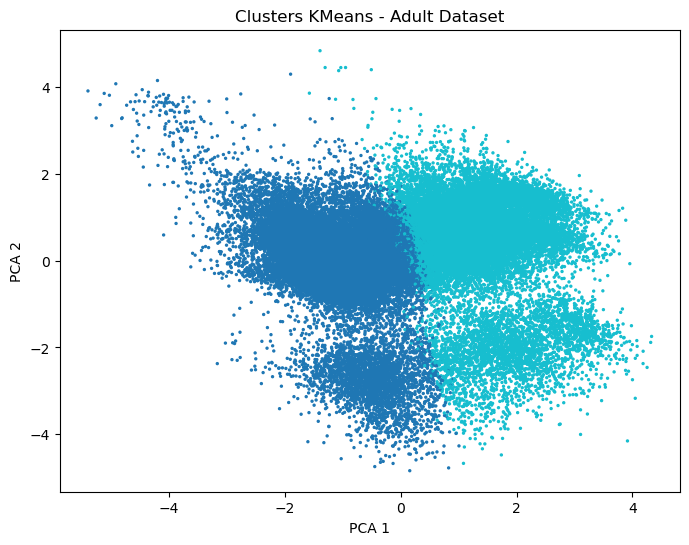

In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_nor)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred, s=2, cmap="tab10")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters KMeans - Adult Dataset")
plt.show()


In [26]:
from sklearn.metrics import silhouette_samples, silhouette_score


score = silhouette_score(X_nor, y_pred)
print("Silhouette Score KMeans:", score)

Silhouette Score KMeans: 0.13687216107334874


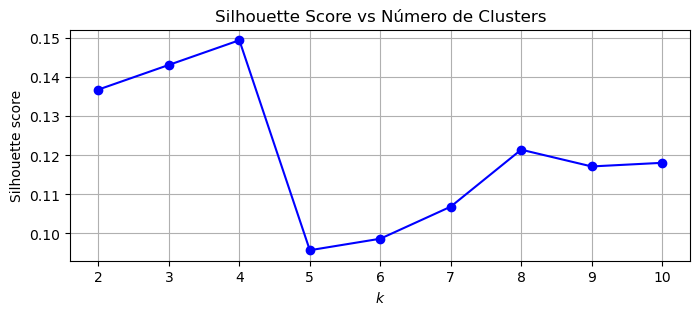

In [27]:
# Silhouette plots para varios k

max_k = 10
kmeans_per_k = [KMeans(n_clusters=i, random_state=42).fit(X_nor) for i in range(2, max_k+1)]
silhouette_scores = [silhouette_score(X_nor, model.labels_) for model in kmeans_per_k]

plt.figure(figsize=(8, 3))
plt.plot(range(2, max_k+1), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs Número de Clusters")
plt.grid(True)
plt.show()


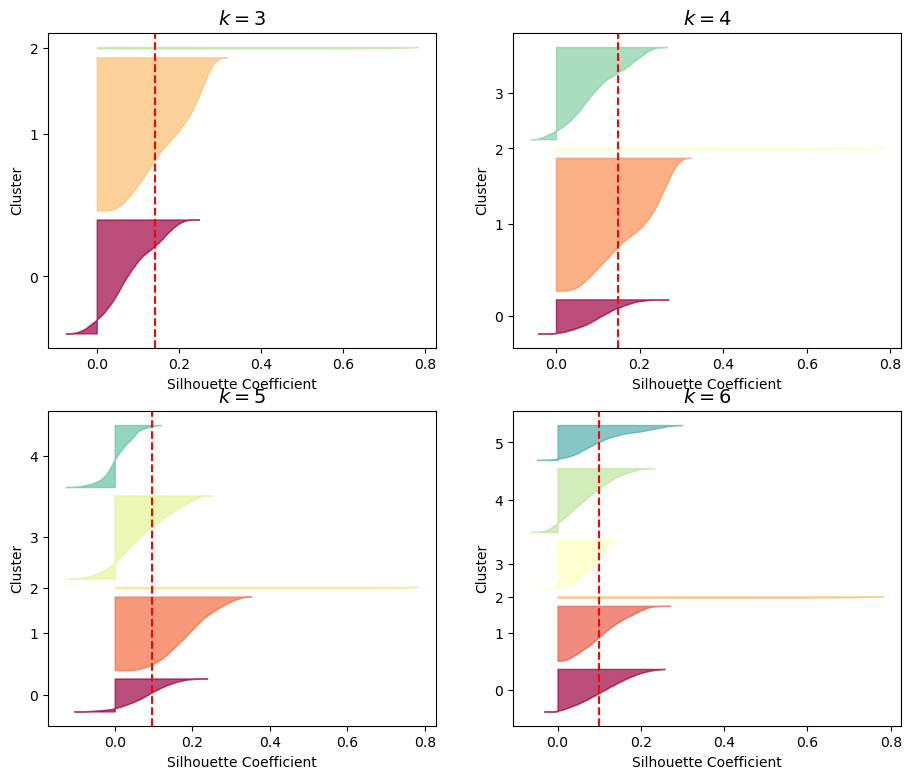

In [28]:
# Silhouette plots detallados para k=3 a 6

from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl


plt.figure(figsize=(11,9))
for plot_idx, k in enumerate(range(3, 7)):
    if k > len(kmeans_per_k)+1:
        continue
    plt.subplot(2,2,plot_idx+1)
    y_pred = kmeans_per_k[k-2].labels_
    sil_samples = silhouette_samples(X_nor, y_pred)

    padding = len(X_nor)//30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = sil_samples[y_pred==i]
        coeffs.sort()
        color = mpl.cm.Spectral(i/k)
        plt.fill_betweenx(np.arange(pos, pos+len(coeffs)), 0, coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs)//2)
        pos += len(coeffs) + padding
    
    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")
    plt.xlabel("Silhouette Coefficient")
    plt.axvline(x=silhouette_scores[k-2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.show()